In this code we calculate the averaged Breit-Wheeler cross-section across the two-dimensional phase space of photon-photon pair production. The code scans a grid of gamma-ray energies and background target photon energies to evaluate the interaction probability. By integrating over the collision angles, it constructs the full interaction phase space map for high-energy astrophysics applications. It generates a 2D logarithmic colormap plot displaying the Breit-Wheeler cross-section as a function of gamma-ray energies and target photon energy. 

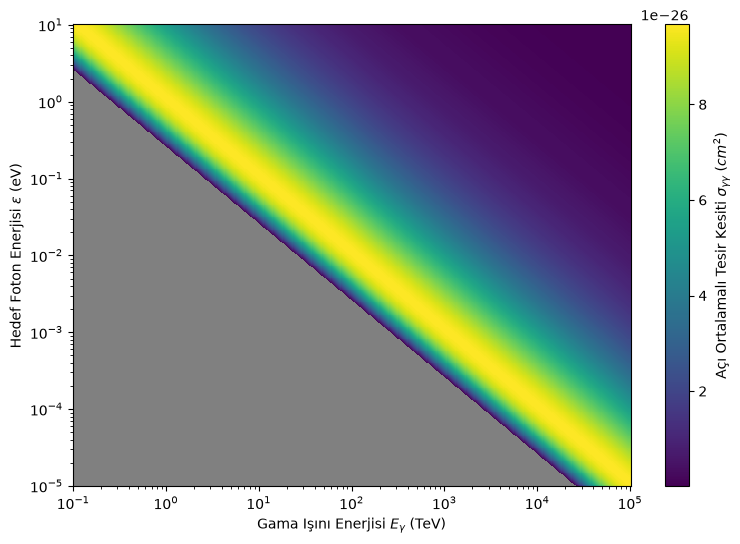

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Defining the phase space
E_gamma = np.logspace(11,17,500)
epsilon = np.logspace(-5,1,500)
theta = np.linspace(0,360,360)
# x = 2(mc^2)^2
x = 5.2224e11 
# y = constant of sigma
y = 1.25e-25

# Defining cross section functions
def s(E_gamma,epsilon,theta):
    theta_rad = np.radians(theta)
    result = E_gamma*epsilon*(1-np.cos(theta_rad))/x
    return result

def B(s):
    if s >= 1:
        B = np.sqrt(1-1/s)
        return B
    else:
        return 0.0

def sigma(B):
    if B==0 or B>=1.0:
        return 0.0
    else:
        result = y*(1-B**2)*((3-B**4)*np.log((1+B)/(1-B))-2*B*(2-B**2))
        return result
        

# Create a matrix for sigma and calculate angle averaged sigma values
Sigma_matrix = np.zeros((len(E_gamma),len(epsilon))) 
for i,E in enumerate(E_gamma):
    for j,eps in enumerate(epsilon):
        sigma_sum=0.0
        for th in theta:
            s_val = s(E,eps,th)
            B_val = B(s_val)
            sigma_val = sigma(B_val)
            sigma_sum += sigma_val
        sigma_avr= sigma_sum / 360 
        Sigma_matrix[i,j] = sigma_avr

# Making zero values gray on the plot
Sigma_zeros = np.where(Sigma_matrix == 0, np.nan, Sigma_matrix)
# Plot 2D cross section map

X, Y = np.meshgrid(E_gamma / 1e12, epsilon)
plt.figure(figsize=(9,6))
current_cmap = plt.colormaps['viridis'].copy()
current_cmap.set_bad(color='gray')
plt.pcolormesh(X,Y,Sigma_zeros.T, cmap=current_cmap, shading='auto')
plt.colorbar(label=r'Açı Ortalamalı Tesir Kesiti $\sigma_{\gamma\gamma}$ ($cm^2$)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Gama Işını Enerjisi $E_\gamma$ (TeV)')
plt.ylabel(r'Hedef Foton Enerjisi $\epsilon$ (eV)')
plt.savefig('Figure1_2.png')
plt.show()
